In [ ]:
import numpy as np

# Load .npz file

datapath ='./data_unifmir/Isotropic/Isotropic_Liver/train_data/data_label.npz'
data = np.load('/./data_unifmir/Isotropic/Isotropic_Liver/train_data/data_label.npz')

In [ ]:
# Load tif file

import tifffile as tiff
image = tiff.imread('./data_unifmir/Isotropic/Isotropic_Liver/test_data/input_subsample_8.tif')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
index = index+1
x_sample = data["X"][index, 0, :, :]  # (128, 128)
y_sample = data["Y"][index, 0, :, :]   


plt.imshow(x_sample, cmap='gray') 
plt.title(f"X Sample: {index}")
plt.show()

plt.imshow(y_sample, cmap='gray') 
plt.title(f"Y Sample: {index}")
plt.show()

In [ ]:
from torch.utils.data import Dataset
import torch
import os
from csbdeep.io import load_training_data
from tifffile import imread


class Flouresceneiso(Dataset):
    def __init__(self, datapath, validation_split=0.05, istrain=True):
        self.datapath = datapath
        self.batch = 1
        self.datamin, self.datamax = 0, 100
        self.istrain = istrain
        self.patch_size = 128
        self.rgb_range = 1
        self.validation_split = validation_split

        self.iso = ['Isotropic_Liver']
        if istrain:
            self._scanisonpy()
        else:
            self._scaniso()
            
        if istrain:
            print('++ ++ ++ ++ ++ ++ length of training images = ', self.lenth, '++ ++ ++ ++ ++ ++')
        else:
            print('++ ++ ++ ++ ++ ++ length of test images = ', self.lenth, '++ ++ ++ ++ ++ ++')
        
    def _scanisonpy(self):
        hr = []
        lr = []
        patch_size = self.patch_size
    
        datapath = f'{self.datapath}/Isotropic/'
        for i in self.iso:
            # Liver X/Y (3872, 128, 128, 1)
            X, Y, _, _ = self.loadData(datapath + '%s/train_data/data_label.npz' % i, axes='SCYX', validation_split=0.0)
            
            print('Dataset:', i, 'np.isnan(X).any(), np.isnan(Y).any()', np.isnan(X).any(), np.isnan(Y).any())
            print('X.shape, Y.shape = ', X.shape, Y.shape)
            height, width = X.shape[1:3]
            assert len(X) == len(Y)
            
            if patch_size < height:
                X1 = []
                Y1 = []
                for n in range(len(X)):
                    for i in range(0, width, patch_size):
                        for j in range(0, height, patch_size):
                            X1.append(X[n][j:j + patch_size, i:i + patch_size, :])
                            Y1.append(Y[n][j:j + patch_size, i:i + patch_size, :])
                hr.extend(Y1)
                lr.extend(X1)
            else:
                hr.extend(Y)
                lr.extend(X)

        self.nm_hriso, self.nm_lriso = hr, lr
        self.lenth = len(self.nm_lriso)

    def _scaniso(self):
        hr = []
        lr = []
        for i in self.iso:
            self.dir_lr = f'{self.datapath}/Isotropic/%s/test_data/' % i
            hr.append(self.dir_lr + 'input_subsample_1_groundtruth.tif')  # Liver [301, 752, 752]
            lr.append(self.dir_lr + 'input_subsample_8.tif')
            
        self.nm_hr, self.nm_lr = hr, lr
        self.lenth = len(self.nm_lr)

    def __getitem__(self, idx):
        idx = idx % self.lenth
        if self.istrain:
            lr, hr, filename = self._load_file_iso_npy(idx)
        else:
            lr, hr, filename = self._load_file_isotest(idx)
        lr = torch.from_numpy(np.ascontiguousarray(lr * self.rgb_range)).float()
        hr = torch.from_numpy(np.ascontiguousarray(hr * self.rgb_range)).float()
        
        return lr, hr, torch.tensor(0)
    
    def __len__(self):
        return self.lenth

    def _load_file_iso_npy(self, idx):
        lr = []
        hr = []
        for i in range(self.batch):
            idn = (idx + i) % self.lenth
            hr.append(self.nm_hriso[idn])
            lr.append(self.nm_lriso[idn])
    
        rgb = np.concatenate(hr, -1)
        rgblr = np.concatenate(lr, -1)
        rgb = np.transpose(np.float32(rgb), (2, 0, 1))  # [1, 128, 128]
        rgblr = np.transpose(np.float32(rgblr), (2, 0, 1))
    
        return rgblr, rgb, ''

    def _load_file_isotest(self, idx):
        filename, i = os.path.splitext(os.path.basename(self.nm_lr[idx]))
        rgblr = np.float32(imread(self.nm_lr[idx]))

        # Liver [301, 752, 752]
        hrp = self.nm_lr[idx].replace('_8.tif', '_1_groundtruth.tif')
        try:
            rgb = np.float32(imread(hrp))
        except:
            rgb = np.ones([301, 752, 752])
        
        return rgblr, rgb, filename
    
    def loadData(self, traindatapath, axes='SCYX', validation_split=0.05):
        print('Load data npz')
        if validation_split > 0:
            (X, Y), (X_val, Y_val), axes = load_training_data(traindatapath, validation_split=validation_split, axes=axes, verbose=True)
        else:
            (X, Y), _, axes = load_training_data(traindatapath, validation_split=validation_split, axes=axes, verbose=True)
            X_val, Y_val = 0, 1
        print(X.shape, Y.shape)  # (18468, 128, 128, 1) (18468, 256, 256, 1)
        return X, Y, X_val, Y_val

In [ ]:
class Args:
    def __init__(self):
        self.patch_size = 128
        self.rgb_range = 1

def get_args():
    return Args()

args = get_args()
args.patch_size

In [ ]:
class ISOLiverDataset(Dataset):
    def __init__(self, config, is_train=True):
        """
        Args:
            config: 配置对象
            is_train: 是否为训练模式
        """
        self.data_dir = config.data_dir
        self.is_train = is_train
        
        # 加载数据集信息
        info = np.load(os.path.join(self.data_dir, 'dataset_info.npy'), allow_pickle=True).item()
        self.original_shape = info['original_test_shape'] if not is_train else None
        
        # 获取文件列表
        if is_train:
            self.file_list = sorted(glob.glob(os.path.join(self.data_dir, 'train', 'cluster_*.npz')))
        else:
            self.file_list = sorted(glob.glob(os.path.join(self.data_dir, 'test', 'patch_*.npz')))
            
        print(f"{'Train' if is_train else 'Test'} dataset initialized with {len(self.file_list)} samples")
        
        # 加载第一个文件以获取数据形状
        sample_data = np.load(self.file_list[0])
        source_shape = sample_data['source'].shape
        print(f"Original data shape: {source_shape}")
        
        if not is_train:
            # 仅测试集需要patch坐标信息
            self.patch_coords = []
            for file_path in self.file_list:
                data = np.load(file_path)
                self.patch_coords.append(data['position'])

    def __getitem__(self, idx):
        data = np.load(self.file_list[idx])
        source = data['source']
        target = data['target']
            
        # 转换为tensor并添加维度
        source = torch.from_numpy(source).float()
        target = torch.from_numpy(target).float()
        
    
        if self.is_train:
            return source, target
        else:
            position = data['position']
            source = source.squeeze(0)
            target = target.squeeze(0)
            return source, target, position

    def __len__(self):
        return len(self.file_list)

In [ ]:
import h5py

data1_path = '/home/zch/Documents/foundation_mamba_biomed/data_U2fusion/vis_ir_dataset64.h5'
data2_path = '/home/zch/Documents/foundation_mamba_biomed/data_U2fusion/oe_ue_Y_dataset64.h5'
data3_path = '/home/zch/Documents/foundation_mamba_biomed/data_U2fusion/far_near_Y_dataset64.h5'

source_data2 = h5py.File(data1_path, 'r')
source_data2['data']


In [ ]:
source_data2['data'].shape


In [ ]:
class U2FusionDataset(Dataset):
    def __init__(self, config):
        """
        Args:
            config: 配置对象
            is_train: 是否为训练模式
        """
        self.data_path = config.data_dir
        
        source_data = h5py.File(self.data_path, 'r')

        source_data = source_data['data'][:]
        self.source_data = np.transpose(source_data, (0, 3, 2, 1)) # (N, H, W, C)
        print("source_data shape:", source_data.shape)

    def __getitem__(self, idx):
        data = np.load(self.file_list[idx])
        source = data['source']
        target = data['target']
            
        # 转换为tensor并添加维度
        source = torch.from_numpy(source).float()
        target = torch.from_numpy(target).float()
        
    
        if self.is_train:
            return source, target
        else:
            position = data['position']
            source = source.squeeze(0)
            target = target.squeeze(0)
            return source, target, position

    def __len__(self):
        return len(self.file_list)

In [ ]:
index = 0


In [ ]:
import matplotlib.pyplot as plt


source = source_data2['data'][index][0]
target = source_data2['data'][index][1]

x_sample = source  # (128, 128)
y_sample = target  # ? (需要检查类型和值)


# 可视化 x_sample 和 y_sample（图像）- Subplot 形式
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1 行，2 列，图大小为 (宽度, 高度)

axs[0].imshow(x_sample, cmap='gray')  # 使用灰度 colormap - 左图
axs[0].set_title(f"X Sample: {index}")

axs[1].imshow(y_sample, cmap='gray')  # 使用灰度 colormap - 右图
axs[1].set_title(f"Y Sample: {index}")

# 删除子图之间的空白
fig.tight_layout()

plt.show()

index = index+1


In [ ]:
import numpy as np

source_data2 = source_data2['data'][:]
source_data2 = np.transpose(source_data2, (0, 3, 2, 1))
print("source_data2 shape:", source_data2.shape)

In [ ]:
# 定义基础前缀和编号范围
prefixes = ['mr', 'tc', 'tl']
numbers = range(1, 100)  # 编号范围（1-8），根据需求调整

# 初始化关键词列表
keywords = []

# 生成单一类型的关键词 (e.g., mr1, tc2, tl3)
for prefix in prefixes:
    for number in numbers:
        keywords.append(f"{prefix}{number}")

# 仅生成 mr 与其他前缀的组合 (e.g., mr1-tc1, mr2-tl3)
mr_combinations = ['tc', 'tl']  # 仅考虑 mr 与这些前缀的组合
for number1 in numbers:
    for prefix2 in mr_combinations:
        for number2 in numbers:
            keywords.append(f"mr{number1}-{prefix2}{number2}")

# 输出关键词列表 (按字母顺序排序)
for keyword in sorted(keywords):
    print(keyword)

In [ ]:
import requests
import os

# 目标网站基本路径
base_url = "https://www.med.harvard.edu/AANLIB/cases/"

# 批量下载参数
cases = range(1, 100)  # case 从 1 到 99
# categories = ["mr1", "mr2", "mr3", "tc1", "tc2", "tc3", "mr1-tc2", "mr2-tc3"]  # 图片类型关键词
categories = keywords
slices = range(0, 100)  # slice 编号假设从 1 到 99，根据实际情况调整

# 文件保存路径（请根据自己的需求调整）
save_path = "./downloaded_images"

# 检查保存目录是否存在，若不存在则创建
if not os.path.exists(save_path):
    os.makedirs(save_path)

for case in cases:
    for category in categories:
        for slice_num in slices:
            # 构造文件名和下载路径
            filename = f"{slice_num:03}.gif"  #确保slice编号为三位数，前缀补零
            download_url = f"{base_url}case{case}/{category}/{filename}"
            
            # 重命名保存的文件
            new_filename = f"case{case}_{category}_{slice_num:03}.gif"
            full_save_path = os.path.join(save_path, new_filename)
            
            try:
                # 发送 HTTP GET 请求，获取图片数据
                response = requests.get(download_url, stream=True)
                
                # 检查请求是否成功
                if response.status_code == 200:
                    # 以二进制写入模式打开文件，开始下载
                    with open(full_save_path, 'wb') as file:
                        for chunk in response.iter_content(1024):
                            file.write(chunk)
                    
                    print(f"图片 {new_filename} 下载成功！保存路径：{full_save_path}")
                else:
                    # 如果文件不存在（404）或其他错误，打印提示
                    if response.status_code == 404:
                        print(f"文件 {download_url} 不存在")
                    else:
                        print(f"失败：无法下载 {download_url}, 状态码：{response.status_code}")
            except Exception as e:
                print(f"错误发生于 {download_url} ：{e}")

In [ ]:
def check_case_valid(case, categories_prefix):
    valid_categories = []
    for num in range(1, 100):  
        category = f"{categories_prefix}{num}"
        if not check_single_category_valid(case, category):
            print(f"Case {case} 下的 {categories_prefix} 类别无效，跳过后续...")
            break  # 遇到第一个无效 category 后停止检查
        else:
            valid_categories.append(category)
    return valid_categories

def check_single_category_valid(case, category):
    # 请实现您的逻辑以检查单个 category 在 case 下是否有效
    # 此处为示例，请根据实际情况修改
    url = f"https://www.med.harvard.edu/AANLIB/cases/case{case}/{category}/000.gif"
    try:
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            return True
        else:
            if response.status_code == 404:
                print(f"文件 {url} 不存在，跳过category {category}")
            else:
                print(f"失败：无法下载 {url}, 状态码：{response.status_code}, 跳过category {category}")
            return False
    except Exception as e:
        print(f"错误发生于 Case {case}, Category {category} ：{e}")
        return False


valid_cases_categories = {}
for case in range(1, 43):
    categories = []

    # 检查 mr 类别
    mr_categories = check_case_valid(case, "mr")
    if mr_categories:
        categories.extend(mr_categories)
    
    # 检查 tl 类别
    tl_categories = check_case_valid(case, "tl")
    if tl_categories:
        categories.extend(tl_categories)

    # 检查 tc 类别
    tc_categories = check_case_valid(case, "tc")
    if tc_categories:
        categories.extend(tc_categories)

    # 检查 ct 类别
    ct_categories = check_case_valid(case, "ct")
    if ct_categories:
        categories.extend(ct_categories)

    # ...检查其他类别...

    if categories:
        valid_cases_categories[case] = categories

# 输出有效的 case-category 列表
print("\n**有效 Case-Category 列表:**")
for case, categories in valid_cases_categories.items():
    for category in categories:
        print(f"{case} - {category}")


In [ ]:
categories

In [ ]:
valid_cases_categories

In [ ]:
def generate_combination_categories(valid_cases_categories):
    combination_categories = {}
    
    for case, categories in valid_cases_categories.items():
        mr_categories = [cat for cat in categories if cat.startswith('mr')]
        other_categories = [cat for cat in categories if cat.startswith(('tc', 'tl', 'ct'))]
        
        if mr_categories and other_categories:
            combinations = [(mr, other) for mr in mr_categories for other in other_categories]
            combination_categories[case] = ['-'.join(combination) for combination in combinations]
    
    return combination_categories

combination_categories = generate_combination_categories(valid_cases_categories)


In [ ]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor

def download_slice(case, category, slice_num, base_url, save_path):
    filename = f"{slice_num:03}.gif"
    download_url = f"{base_url}case{case}/{category}/{filename}"
    new_filename = f"case{case}_{category}_{slice_num:03}.gif"
    full_save_path = os.path.join(save_path, new_filename)

    try:
        response = requests.get(download_url, stream=True)
        if response.status_code == 200:
            with open(full_save_path, 'wb') as file:
                for chunk in response.iter_content(1024):
                    file.write(chunk)
            print(f"图片 {new_filename} 下载成功！保存路径：{full_save_path}")
        else:
            if response.status_code == 404:
                print(f"文件 {download_url} 不存在")
            else:
                print(f"失败：无法下载 {download_url}, 状态码：{response.status_code}")
    except Exception as e:
        print(f"错误：下载 {download_url} 失败 - {str(e)}")


base_url = "https://www.med.harvard.edu/AANLIB/cases/"
save_path = "./downloaded_images"

slices = range(0, 100)  # slice 编号范围

# 确保保存目录存在
os.makedirs(save_path, exist_ok=True)

all_categories = {**valid_cases_categories, **combination_categories}

with ThreadPoolExecutor(max_workers=24) as executor:  # 设定最大线程数为 10
    tasks = []
    for case, categories in valid_cases_categories.items():
        for category in categories:
            for slice_num in slices:
                task = executor.submit(download_slice, case, category, slice_num, base_url, save_path)
                tasks.append(task)
    
    # 等待所有任务完成（可选，但建议保留以确保主线程在子线程完成后退出）
    for task in tasks:
        task.result()


In [ ]:
all_categories

In [ ]:
valid_cases_categories

In [ ]:
combination_categories

In [ ]:
IMAGES_PATH = '/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/downloaded_images'



In [ ]:
import os
import numpy as np
from PIL import Image
from collections import defaultdict

# 假设data_path为数据所在目录路径
data_path = '/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/downloaded_images'
# 存储每个case和模态的3D数据
case_data = defaultdict(lambda: defaultdict(list))

# 遍历目录中的所有文件
for file_name in os.listdir(data_path):
    if file_name.endswith(".gif"):
        # 拆解文件名以提取case、模态和slice序号
        parts = file_name.split('_')
        case_id = parts[0]  # case编号
        modality = parts[1]  # 模态标识
        slice_num = int(parts[-1].split('.')[0])  # slice序号

        # 读取图片
        img_path = os.path.join(data_path, file_name)
        img = Image.open(img_path)
        img_array = np.array(img)

        # 将切片数据存储到对应的case和模态下，并按序号记录
        case_data[case_id][modality].append((slice_num, img_array))

# 创建3D数组并排序
case_3d_arrays = {}
for case_id, modalities in case_data.items():
    case_3d_arrays[case_id] = {}
    for modality, slices in modalities.items():
        # 按slice序号排序
        slices_sorted = sorted(slices, key=lambda x: x[0])
        # 取出排序后的2D数组，并叠加成3D数组
        slices_3d = np.stack([s[1] for s in slices_sorted], axis=-1)
        case_3d_arrays[case_id][modality] = slices_3d

# 现在case_3d_arrays包含每个case、每个模态的3D数组


In [ ]:
case_3d_arrays.keys()

In [ ]:

# 假设case_3d_arrays包含之前生成的每个case、模态的3D数组数据
case_pairs = []

for case_id, modalities in case_3d_arrays.items():
    # 获取所有模态名称
    modality_names = list(modalities.keys())

    # 遍历所有模态名以查找配对
    for modality in modality_names:
        if '-' in modality:
            # 如果模态名包含"-"，表示它可能是一个目标模态（模态1-模态2）
            source1, source2 = modality.split('-')

            # 检查source1和source2是否在当前case中存在
            if source1 in modalities and source2 in modalities:
                # 读取对应的3D数据
                data_source1 = modalities[source1]
                data_source2 = modalities[source2]
                data_target = modalities[modality]
                print(f"Case {case_id}: Found pair {source1}/{source2}/{modality}")

                # 确保三个模态的3D数据形状一致
                if data_source1.shape == data_source2.shape == data_target.shape:
                    case_pairs.append([data_source1, data_source2, data_target])
                else:
                    print(f"Warning: Shapes do not match for case {case_id} with {source1}, {source2}, {modality}")

# 转换为5维数组，形状为 (case数量, 3, 长, 宽, 高)
# case_pairs_array = np.array(case_pairs)

# # 保存到 data.npz 文件
# np.savez("data.npz", data=case_pairs_array)


In [ ]:
import numpy as np

# 假设 case_3d_arrays 包含之前生成的每个 case、模态的 3D 数组数据
case_pairs = []

sorted_cases = sorted(case_3d_arrays.items(), key=lambda x: int(x[0][4:]))

# 遍历所有病例
for case_id, modalities in sorted_cases:
    # 临时列表，用于存储当前病例的配准对
    case_data = []

    # 获取所有模态名称
    modality_names = list(modalities.keys())

    # 遍历所有模态名以查找配对
    for modality in modality_names:
        if '-' in modality:
            # 如果模态名包含 "-", 表示它可能是一个目标模态（模态1-模态2）
            source1, source2 = modality.split('-')

            # 检查 source1 和 source2 是否在当前 case 中存在
            if source1 in modalities and source2 in modalities:
                # 读取对应的 3D 数据
                data_source1 = modalities[source1]
                data_source2 = modalities[source2]
                data_target = modalities[modality]

                # 确保三个模态的 3D 数据形状一致
                if data_source1.shape == data_source2.shape == data_target.shape:
                    # 将 source1, source2, target 叠加为 4 维数组
                    pair_4d = np.stack([data_source1, data_source2, data_target], axis=0)
                    case_data.append(pair_4d)
                else:
                    print(f"Warning: Shapes do not match for case {case_id} with {source1}, {source2}, {modality}")

    # 将当前 case 的配准对数据添加到 case_pairs 列表中
    if case_data:
        case_pairs.append(np.array(case_data))

# 保存为 .npz 文件
obj_array = np.array(case_pairs, dtype=object)

np.savez("data.npz", case_pairs=obj_array)

In [ ]:
sorted_cases[0][1].keys()

In [ ]:
case_pairs[0].shape

In [5]:
import numpy as np

data = np.load("data.npz", allow_pickle=True)

In [6]:
case_pairs = data['case_pairs']

In [ ]:
case_pairs[0].shape


(48, 3, 256, 256, 56)

In [ ]:
case_pairs

In [19]:
# 假设 case_pairs 是一个列表，其中每个元素是一个 shape 为 (num_pair, 3, H, W, D) 的数组
cropped_depth = 8  # 目标 depth
dataset = []  # 用于存储所有裁剪后的数据
stride = 8  # 滑动窗口步长
for case_data in case_pairs:
    # 获取当前 case 的 shape: (num_pair, 3, H, W, D)
    num_pair, channels, height, width, depth = case_data.shape

    # 确定裁剪范围，如果 depth < cropped_depth，可根据需求决定是否补零或跳过
    if depth >= cropped_depth:
        # start = (depth - cropped_depth) // 2 # 从中间开始裁剪
        # start = np.random.randint(0, depth - cropped_depth + 1) # 随机裁剪
        # end = start + cropped_depth
        # cropped_case_data = case_data[:, :, :, :, start:end]
        # 滑动窗口裁剪
        cropped_case_data = []  # 初始化为空列表
        for start in range(0, depth - cropped_depth + 1, stride):
            end = start + cropped_depth
            window = case_data[:, :, :, :, start:end]  # 获取滑动窗口
            print(f"Window shape: {window.shape},")
            cropped_case_data.append(window)  # 直接使用 append
        cropped_case_data = np.concatenate(cropped_case_data, axis=0)  # 使用 np.concatenate 拼接所有窗口
    else:
        print("Depth is less than cropped_depth, depth is ", depth)
        # 如果 depth 不够，可以补零至 cropped_depth
        padding = ((0, 0), (0, 0), (0, 0), (0, 0), (0, cropped_depth - depth))
        cropped_case_data = np.pad(case_data, padding, mode='constant')
    
    # 添加到 dataset
    dataset.append(cropped_case_data)

# # 将所有裁剪后的数据堆叠到一起，形成一个完整的 dataset
final_dataset = np.concatenate(dataset, axis=0)
print(f"Final dataset shape: {final_dataset.shape}")
np.save("finetune_dataset.npy", final_dataset)


Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (48, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (3, 3, 256, 256, 8),
Window shape: (3, 3, 256, 256, 8),
Window shape: (3, 3, 256, 256, 8),
Window shape: (3, 3, 256, 256, 8),
Window shape: (3, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape: (1, 3, 256, 256, 8),
Window shape:

In [3]:
import numpy as np

In [4]:
final_dataset = np.load("/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/finetune_dataset.npy")
print(f"Final dataset shape: {final_dataset.shape}")


Final dataset shape: (513, 3, 256, 256, 8)


In [ ]:
# import torch
# from torch.utils.data import Dataset, DataLoader
# import numpy as np

# # 假设 final_dataset 是形状为 (753, 3, 256, 256, 16) 的 NumPy 数组
# # final_dataset = np.load('finetune_dataset.npy')  # 加载你的最终数据集

# class FATFusionDataset(Dataset):
#     def __init__(self, npy_path):
#         """
#         :param data: 你的数据集 (num_items, 3, H, W, D)
#         """
#         self.data = np.load(npy_path)
#         # self.data = data

#     def __len__(self):
#         """返回数据集的总样本数"""
#         return len(self.data)

#     def __getitem__(self, idx):
#         """
#         获取第 idx 个样本
#         :param idx: 索引
#         :return: (3, D, H, W) 这样的形状
#         """
#         item = self.data[idx]  # 获取单个样本，形状为 (3, H, W, D)

#         # 调整维度顺序从 (3, H, W, D) -> (3, D, H, W)
#         item = np.transpose(item, (0, 3, 1, 2))  # 重新排列轴顺序
#         return torch.tensor(item, dtype=torch.float32)

# # 
# # 创建自定义 Dataset
# # dataset = FATFusionDataset('FATFusion_dataset_supervised.npy')
# dataset = FATFusionDataset('finetune_dataset.npy')


# # 创建 DataLoader
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

# # 示例：迭代 DataLoader 中的数据
# for batch in dataloader:
#     print(batch.shape)  # 输出每个 batch 的形状，应该是 (batch_size, 1, 3, H, W, D)
#     break


torch.Size([32, 3, 8, 256, 256])


In [5]:
import numpy as np
import random
from torch.utils.data import Dataset

# 自定义 Dataset 类
class FATFusionDataset(Dataset):
    def __init__(self, npy_path):
        """
        :param npy_path: 数据集路径 (num_samples, 3, H, W, D)
        """
        self.data = np.load(npy_path)  # 加载 .npy 文件

    def __len__(self):
        """返回数据集的总样本数"""
        return len(self.data)

    def __getitem__(self, idx):
        """
        获取第 idx 个样本，返回 source1, source2, target
        :param idx: 索引
        :return: (source1, source2, target)，每个形状为 (D, H, W)
        """
        item = self.data[idx]  # 获取单个样本，形状为 (3, H, W, D)

        # 分离 source1, source2 和 target
        source1 = item[0, :, :, :]  # 第 1 通道
        source2 = item[1, :, :, :]  # 第 2 通道
        target = item[2, :, :, :]  # 第 3 通道

        # 调整维度顺序从 (H, W, D) -> (D, H, W)
        source1 = np.transpose(source1, (2, 0, 1))  # 变成 (D, H, W)
        source2 = np.transpose(source2, (2, 0, 1))  # 变成 (D, H, W)
        target = np.transpose(target, (2, 0, 1))    # 变成 (D, H, W)

        # Normalize to [0, 1]
        source1 = (source1 - source1.min()) / (source1.max() - source1.min() + 1e-8)
        source2 = (source2 - source2.min()) / (source2.max() - source2.min() + 1e-8)
        target = (target - target.min()) / (target.max() - target.min() + 1e-8)

        # 返回三部分数据
        return (
            torch.tensor(source1, dtype=torch.float32),
            torch.tensor(source2, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32),
        )


# 加载完整数据集
dataset = np.load('finetune_dataset.npy')  # 形状为 (num_samples, 3, H, W, D)
total_size = len(dataset)

# 分割数据集
random.seed(42)  # 保证结果可复现
test_indices = random.sample(range(total_size), 40)  # 随机选 40 个作为 test
remaining_indices = list(set(range(total_size)) - set(test_indices))
val_indices = random.sample(remaining_indices, 30)  # 随机选 30 个作为 val
train_indices = list(set(remaining_indices) - set(val_indices))  # 剩下的作为 train

# 获取子集
test_data = dataset[test_indices]  # (40, 3, H, W, D)
val_data = dataset[val_indices]    # (30, 3, H, W, D)
train_data = dataset[train_indices]  # (剩余数量, 3, H, W, D)

# 保存子集为 .npy 文件
np.save('test_data.npy', test_data)
np.save('val_data.npy', val_data)
np.save('train_data.npy', train_data)


In [6]:
len(test_data)

40

In [64]:
for batch in train_data_loader:
    print(batch.shape)  # 输出每个 batch 的形状，应该是 (batch_size, 1, 3, H, W, D)
    break

torch.Size([32, 1, 3, 256, 256, 8])


In [ ]:
import os
class FATFusionDataset(Dataset):
    def __init__(self, config, is_train = True):
        if is_train:
            self.data = np.load(os.path.join(config.data_dir, 'train_data.npy'))
        else:
            self.data = np.load(os.path.join(config.data_dir, 'test_data.npy'))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        获取第 idx 个样本，返回 source1, source2, target
        :param idx: 索引
        :return: (source1, source2, target)，每个形状为 (D, H, W)
        """
        item = self.data[idx]  # 获取单个样本，形状为 (3, H, W, D)

        # 分离 source1, source2 和 target
        source1 = item[0, :, :, :]  # 第 1 通道
        source2 = item[1, :, :, :]  # 第 2 通道
        target = item[2, :, :, :]  # 第 3 通道

        # 调整维度顺序从 (H, W, D) -> (D, H, W)
        source1 = np.transpose(source1, (2, 0, 1))  # 变成 (D, H, W)
        source2 = np.transpose(source2, (2, 0, 1))  # 变成 (D, H, W)
        target = np.transpose(target, (2, 0, 1))    # 变成 (D, H, W)

        # 返回三部分数据
        return (
            torch.tensor(source1, dtype=torch.float32),
            torch.tensor(source2, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32),
        )
    
class Config():
    pass
config = Config()
config.data_dir = '/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D'
train_dataset = FATFusionDataset(config, is_train=True)

In [95]:
a = np.load("/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/train_data.npy")

In [96]:
a.shape

(443, 3, 256, 256, 8)

In [100]:
a,b,c=train_dataset[0]

In [101]:
a.shape

torch.Size([8, 256, 256])

In [57]:
test_dataset = FATFusionDataset('test_data.npy')
test_dataset[0].shape

torch.Size([1, 3, 256, 256, 8])

In [ ]:
case_3d_arrays.keys()

In [ ]:
import numpy as np

# 假设 case_3d_arrays 包含之前生成的每个 case、模态的 3D 数组数据
case_pairs = []
cropped_depth = 32  # 目标 depth
dataset = []  # 用于存储所有裁剪后的数据

# 按 case 排序
sorted_cases = sorted(case_3d_arrays.items(), key=lambda x: int(x[0][4:]))

# 遍历所有病例
for case_id, modalities in sorted_cases:
    # 临时列表，用于存储当前病例的配准对
    case_data = []

    # 获取所有模态名称
    modality_names = list(modalities.keys())

    # 遍历所有模态名以查找配对
    for modality in modality_names:
        if '-' in modality:
            # 如果模态名包含 "-", 表示它可能是一个目标模态（模态1-模态2）
            source1, source2 = modality.split('-')

            # 检查 source1 和 source2 是否在当前 case 中存在
            if source1 in modalities and source2 in modalities:
                # 读取对应的 3D 数据
                data_source1 = modalities[source1]
                data_source2 = modalities[source2]
                data_target = modalities[modality]

                # 确保三个模态的 3D 数据形状一致
                if data_source1.shape == data_source2.shape == data_target.shape:
                    # 将 source1, source2, target 叠加为 4 维数组
                    pair_4d = np.stack([data_source1, data_source2, data_target], axis=0)
                    case_data.append(pair_4d)
                else:
                    print(f"Warning: Shapes do not match for case {case_id} with {source1}, {source2}, {modality}")

    # 将当前 case 的配准对数据裁剪并保存到 dataset
    if case_data:
        case_data_array = np.array(case_data)
        num_pair, channels, height, width, depth = case_data_array.shape

        # 确定裁剪范围，如果 depth < cropped_depth，记录不足的 case 和 modality
        if depth >= cropped_depth:
            # 从中间裁剪出 cropped_depth
            start = (depth - cropped_depth) // 2
            end = start + cropped_depth
            cropped_case_data = case_data_array[:, :, :, :, start:end]
        else:
            print(f"Case {case_id} has depth {depth}, which is less than cropped_depth")
            # 如果 depth 不够，补零至 cropped_depth
            padding = ((0, 0), (0, 0), (0, 0), (0, 0), (0, cropped_depth - depth))
            cropped_case_data = np.pad(case_data_array, padding, mode='constant')
        
        # 添加裁剪后的数据到 dataset
        dataset.append(cropped_case_data)

# 将所有裁剪后的数据堆叠到一起，形成一个完整的 dataset
final_dataset = np.concatenate(dataset, axis=0)
print(f"Final dataset shape: {final_dataset.shape}")

# 保存裁剪后的 dataset
np.save("finetune_dataset.npy", final_dataset)


In [14]:
dataset[0].shape

torch.Size([1, 3, 256, 256, 16])

In [ ]:
test_dataset

In [36]:
test_dataset[10].shape

torch.Size([1, 3, 256, 256, 8])

Text(0.5, 1.0, 'Target')

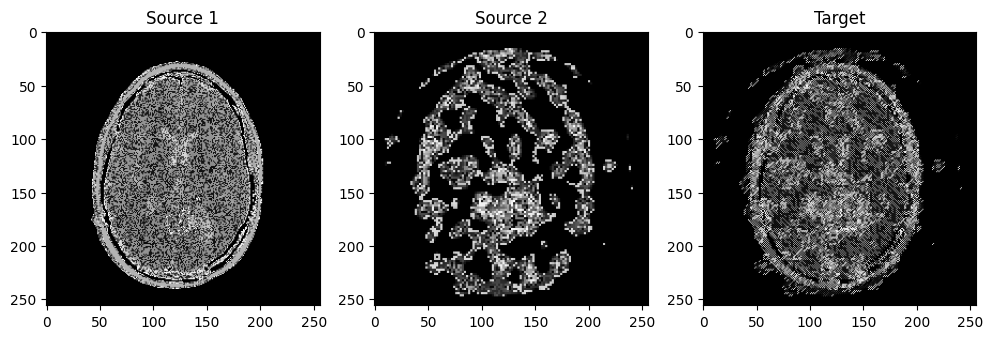

In [ ]:
this_bundle = test_dataset[10][0]
slice = 6
# plot this bundle
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(this_bundle[0, :, :, slice], cmap='gray')
plt.title('Source 1')
plt.subplot(132)
plt.imshow(this_bundle[1, :, :, slice], cmap='gray')
plt.title('Source 2')
plt.subplot(133)
plt.imshow(this_bundle[2, :, :, slice], cmap='gray')
plt.title('Target')


mr1-tc1 mr2-tc1 mr2-tc3 mr1 tc1 mr1-tc1

In [4]:
case_pairs[0].shape

(48, 3, 256, 256, 56)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

data = np.load("data.npz", allow_pickle=True)
case_pairs = data['case_pairs']

# case_pairs 是一个列表，其中每个元素是一个 shape 为 (num_pair, 3, H, W, D) 的数组
cropped_depth = 32  # 目标 depth 这个可能要改成32
dataset = []  # 用于存储所有裁剪后的数据
stride = 8  # 滑动窗口步长
for case_data in case_pairs:
    # 获取当前 case 的 shape: (num_pair, 3, H, W, D)
    num_pair, channels, height, width, depth = case_data.shape

    # 确定裁剪范围，如果 depth < cropped_depth，可根据需求决定是否补零或跳过
    if depth >= cropped_depth:
        # start = (depth - cropped_depth) // 2 # 从中间开始裁剪
        # start = np.random.randint(0, depth - cropped_depth + 1) # 随机裁剪
        # end = start + cropped_depth
        # cropped_case_data = case_data[:, :, :, :, start:end]
        # 滑动窗口裁剪
        cropped_case_data = []  # 初始化为空列表
        for start in range(0, depth - cropped_depth + 1, stride):
            end = start + cropped_depth
            window = case_data[:, :, :, :, start:end]  # 获取滑动窗口
            print(f"Window shape: {window.shape},")
            cropped_case_data.append(window)  # 直接使用 append
        cropped_case_data = np.concatenate(cropped_case_data, axis=0)  # 使用 np.concatenate 拼接所有窗口
    else:
        print("Depth is less than cropped_depth, depth is ", depth)
        # 如果 depth 不够，可以补零至 cropped_depth
        padding = ((0, 0), (0, 0), (0, 0), (0, 0), (0, cropped_depth - depth))
        cropped_case_data = np.pad(case_data, padding, mode='constant')
    
    # 添加到 dataset
    dataset.append(cropped_case_data)

# # 将所有裁剪后的数据堆叠到一起，形成一个完整的 dataset
cropped_dataset = np.concatenate(dataset, axis=0)
print(f"Final dataset shape: {cropped_dataset.shape}")
# np.save("finetune_dataset.npy", final_dataset)

# final_dataset = np.load("./finetune_dataset.npy")
# print(f"Final dataset shape: {final_dataset.shape}")


# 加载完整数据集
# final_dataset = np.load('finetune_dataset.npy')  # 形状为 (num_samples, 3, H, W, D)
total_size = len(cropped_dataset)

# 分割数据集
random.seed(42)  # 保证结果可复现
test_indices = random.sample(range(total_size), 40)  # 随机选 40 个作为 test
remaining_indices = list(set(range(total_size)) - set(test_indices))
val_indices = random.sample(remaining_indices, 30)  # 随机选 30 个作为 val
train_indices = list(set(remaining_indices) - set(val_indices))  # 剩下的作为 train

# 获取子集
test_data = cropped_dataset[test_indices]  # (40, 3, H, W, D)
val_data = cropped_dataset[val_indices]    # (30, 3, H, W, D)
train_data = cropped_dataset[train_indices]  # (剩余数量, 3, H, W, D)

# 保存子集为 .npy 文件
np.save('./depth32/test_data.npy', test_data)
np.save('./depth32/val_data.npy', val_data)
np.save('./depth32/train_data.npy', train_data)

Depth is less than cropped_depth, depth is  56
Depth is less than cropped_depth, depth is  44
Depth is less than cropped_depth, depth is  26
Depth is less than cropped_depth, depth is  54
Depth is less than cropped_depth, depth is  46
Depth is less than cropped_depth, depth is  20
Depth is less than cropped_depth, depth is  28
Depth is less than cropped_depth, depth is  17
Depth is less than cropped_depth, depth is  24
Depth is less than cropped_depth, depth is  24
Depth is less than cropped_depth, depth is  43
Depth is less than cropped_depth, depth is  32
Depth is less than cropped_depth, depth is  24
Depth is less than cropped_depth, depth is  24
Depth is less than cropped_depth, depth is  10
Depth is less than cropped_depth, depth is  28
Depth is less than cropped_depth, depth is  24
Depth is less than cropped_depth, depth is  25
Depth is less than cropped_depth, depth is  29
Depth is less than cropped_depth, depth is  23
Depth is less than cropped_depth, depth is  43
Depth is less

In [26]:
from scipy.ndimage import zoom
import numpy as np
import random

data = np.load("data.npz", allow_pickle=True)
case_pairs = data['case_pairs']

# case_pairs 是一个列表，其中每个元素是一个 shape 为 (num_pair, 3, H, W, D) 的数组
cropped_depth = 32  # 目标 depth
dataset = []  # 用于存储插值后的数据

for case_data in case_pairs:
    # 获取当前 case 的 shape: (num_pair, 3, H, W, D)
    num_pair, channels, height, width, depth = case_data.shape
    
    # 计算插值比例
    scale = cropped_depth / depth
    
    # 插值处理
    resized_case_data = zoom(case_data, (1, 1, 1, 1, scale), order=1)  # 线性插值
    print(f"Original depth: {depth}, Resized depth: {resized_case_data.shape[-1]}")
    
    # 添加到 dataset
    dataset.append(resized_case_data)

# 将所有插值后的数据堆叠到一起
cropped_dataset = np.concatenate(dataset, axis=0)
print(f"Final dataset shape: {cropped_dataset.shape}")

# 数据集分割
total_size = len(cropped_dataset)

random.seed(42)  # 保证结果可复现
test_indices = random.sample(range(total_size), 15)  # 随机选 40 个作为 test
remaining_indices = list(set(range(total_size)) - set(test_indices))
val_indices = random.sample(remaining_indices, 10)  # 随机选 30 个作为 val
train_indices = list(set(remaining_indices) - set(val_indices))  # 剩下的作为 train

# 获取子集
test_data = cropped_dataset[test_indices]  # (40, 3, H, W, D)
val_data = cropped_dataset[val_indices]    # (30, 3, H, W, D)
train_data = cropped_dataset[train_indices]  # (剩余数量, 3, H, W, D)

# 保存子集为 .npy 文件
np.save('./depth32_new/test_data.npy', test_data)
np.save('./depth32_new/val_data.npy', val_data)
np.save('./depth32_new/train_data.npy', train_data)


Original depth: 56, Resized depth: 32
Original depth: 44, Resized depth: 32
Original depth: 26, Resized depth: 32
Original depth: 54, Resized depth: 32
Original depth: 46, Resized depth: 32
Original depth: 20, Resized depth: 32
Original depth: 28, Resized depth: 32
Original depth: 17, Resized depth: 32
Original depth: 24, Resized depth: 32
Original depth: 24, Resized depth: 32
Original depth: 43, Resized depth: 32
Original depth: 32, Resized depth: 32
Original depth: 24, Resized depth: 32
Original depth: 24, Resized depth: 32
Original depth: 10, Resized depth: 32
Original depth: 28, Resized depth: 32
Original depth: 24, Resized depth: 32
Original depth: 25, Resized depth: 32
Original depth: 29, Resized depth: 32
Original depth: 23, Resized depth: 32
Original depth: 43, Resized depth: 32
Original depth: 55, Resized depth: 32
Final dataset shape: (99, 3, 256, 256, 32)


FileNotFoundError: [Errno 2] No such file or directory: './depth32_new/test_data.npy'

In [28]:
# 保存子集为 .npy 文件
np.save('/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/depth32_new/test_data.npy', test_data)
np.save('/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/depth32_new/val_data.npy', val_data)
np.save('/home/zch/Documents/foundation_mamba_biomed/2D/foundation_mamba_biomed/3D/depth32_new/train_data.npy', train_data)

In [25]:
val_data.shape

(30, 3, 256, 256, 32)

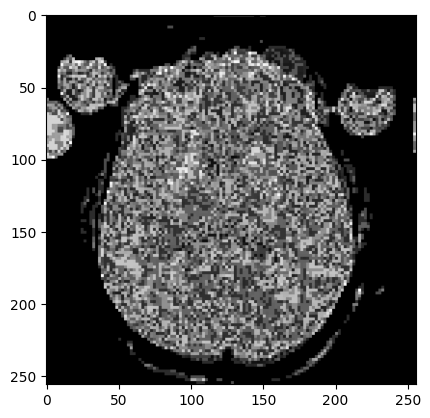

In [17]:
import matplotlib.pyplot as plt
plt.imshow(test_data[0,0, :, :, 16], cmap='gray')